# BART-Large-CNN Fine-Tuning — Kaggle Edition
### CNN/DailyMail Dataset | 100K Samples | Kaggle GPU (P100/T4)
**Authors:** Danyal & Nauman Irshad  
**Model:** facebook/bart-large-cnn  
**Task:** Abstractive News Summarization  
**Metrics:** ROUGE-1, ROUGE-2, ROUGE-L, BERTScore

> **Kaggle Setup:**
> - Settings → Accelerator → GPU (T4 x2 or P100)
> - Settings → Internet → On (needed to download model & dataset)
> - Add HuggingFace token: Add-ons → Secrets → `HF_TOKEN`
>
> **Space Strategy (20 GB limit):**  
> All outputs go to `/kaggle/working/bart_finetuning/`.  
> Checkpoints are aggressively pruned — only the **best** and **1 latest step** checkpoint are kept on disk at any time.  
> The dataset cache is redirected into `/kaggle/working/hf_cache/` so it counts against the quota but stays in one known place you can wipe if needed.

## Cell 0 — Disk Audit (Run First!)
Always run this before anything else to see your baseline free space.

In [1]:
import shutil, os

def disk_report():
    paths = [
        ('/kaggle/working',   'Working dir (your 20 GB quota)'),
        ('/kaggle/input',     'Input datasets (read-only, free)'),
        ('/',                 'Root filesystem'),
    ]
    print(f"{'Path':<35} {'Total':>8} {'Used':>8} {'Free':>8}")
    print("-" * 62)
    for p, label in paths:
        try:
            u = shutil.disk_usage(p)
            print(f"{label:<35} {u.total/1e9:>7.1f}G {u.used/1e9:>7.1f}G {u.free/1e9:>7.1f}G")
        except Exception as e:
            print(f"{label:<35} ERROR: {e}")

disk_report()

# Redirect HuggingFace cache into /kaggle/working so we can monitor it
HF_CACHE = '/kaggle/working/hf_cache'
os.makedirs(HF_CACHE, exist_ok=True)
os.environ['HF_HOME']          = HF_CACHE
os.environ['TRANSFORMERS_CACHE'] = HF_CACHE
os.environ['HF_DATASETS_CACHE']  = os.path.join(HF_CACHE, 'datasets')
print(f"\n✅ HuggingFace cache → {HF_CACHE}")

Path                                   Total     Used     Free
--------------------------------------------------------------
Working dir (your 20 GB quota)         21.0G     0.0G    20.9G
Input datasets (read-only, free)       21.0G     0.0G    20.9G
Root filesystem                      8656.9G  7346.4G  1310.5G

✅ HuggingFace cache → /kaggle/working/hf_cache


## Cell 1 — Install Dependencies

In [2]:
# Most packages are pre-installed on Kaggle; only install what's missing
!pip install -q --no-deps rouge_score==0.1.2
!pip install -q evaluate==0.4.1 bert_score==0.3.13 transformers==4.40.0 \
              datasets==2.19.0 accelerate==0.29.3 sentencepiece==0.2.0

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
print('✅ Dependencies ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 3.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 73.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 91.4 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are instal

## Cell 2 — Imports, Config & Space Utilities

In [3]:
import os, gc, json, glob, math, time, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

try:
    from torch.amp import autocast, GradScaler
    AUTOCAST_DEVICE = 'cuda'
except ImportError:
    from torch.cuda.amp import autocast, GradScaler
    AUTOCAST_DEVICE = None

from transformers import (
    BartForConditionalGeneration, BartTokenizer,
    get_linear_schedule_with_warmup, set_seed
)
from datasets import load_dataset
import evaluate
from huggingface_hub import HfApi

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
set_seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU    : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Paths: all under /kaggle/working to stay within quota ─────────────────
BASE_DIR = '/kaggle/working/bart_finetuning'
CKPT_DIR = os.path.join(BASE_DIR, 'checkpoints')
OUT_DIR  = os.path.join(BASE_DIR, 'bart_news_summarizer')
for d in [CKPT_DIR, OUT_DIR]:
    os.makedirs(d, exist_ok=True)
print(f'\n📁 Base dir : {BASE_DIR}')

# ── Space helpers ──────────────────────────────────────────────────────────
def disk_free_gb(path='/kaggle/working'):
    try:
        return shutil.disk_usage(path).free / 1e9
    except Exception:
        return 999.0

def disk_used_gb(path='/kaggle/working'):
    try:
        u = shutil.disk_usage(path)
        return u.used / 1e9
    except Exception:
        return 0.0

def gpu_info():
    if not torch.cuda.is_available():
        return 'CPU only'
    alloc = torch.cuda.memory_allocated() / 1e9
    resv  = torch.cuda.memory_reserved()  / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    return f'GPU {alloc:.1f}/{total:.1f} GB alloc | {resv:.1f} GB reserved'

def clear_gpu_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def print_space_status(label=''):
    free = disk_free_gb()
    used = disk_used_gb()
    bar_len = 30
    filled  = int(bar_len * used / 20.0)
    bar     = '█' * filled + '░' * (bar_len - filled)
    color   = '🔴' if free < 3 else ('🟡' if free < 6 else '🟢')
    print(f'{color} Disk [{bar}] {used:.1f}/{20:.0f} GB used  |  {free:.1f} GB free  {label}')

# ── Global config — tuned for Kaggle 20 GB ────────────────────────────────
CFG = {
    # Model
    'model_name'        : 'facebook/bart-large-cnn',
    'max_input_length'  : 512,
    'max_target_length' : 128,

    # Data
    'train_samples'     : 90_000,
    'val_samples'       : 5_000,
    'test_samples'      : 5_000,

    # Training
    'epochs'            : 3,
    'train_batch_size'  : 4,
    'eval_batch_size'   : 8,
    'grad_accum_steps'  : 4,
    'learning_rate'     : 3e-5,
    'warmup_ratio'      : 0.05,
    'weight_decay'      : 0.01,
    'max_grad_norm'     : 1.0,
    'fp16'              : True,

    # ── Kaggle-specific space settings ────────────────────────────────────
    'checkpoint_dir'    : CKPT_DIR,
    'save_every_steps'  : 500,
    # Only 1 rolling step checkpoint + 1 best checkpoint at a time
    'keep_last_n'       : 1,
    # Don't attempt to save if free space drops below this
    'min_free_gb'       : 3.0,
    # Save checkpoints in fp16 to halve their size (~1.6 GB → ~0.8 GB)
    'save_fp16_ckpt'    : True,
    # Drop optimizer & scheduler from epoch checkpoints (saves ~4 GB/ckpt)
    'epoch_ckpt_lightweight': True,
    'output_dir'        : OUT_DIR,
    'results_dir'       : BASE_DIR,

    # Generation
    'gen_max_length'    : 80,
    'gen_min_length'    : 30,
    'num_beams'         : 4,
    'length_penalty'    : 2.0,
    'early_stopping'    : True,
    'no_repeat_ngram'   : 3,
}

print_space_status('(after imports)')
print(f'\n⚙️  Config loaded | min_free_gb={CFG["min_free_gb"]} | keep_last_n={CFG["keep_last_n"]}')

2026-05-11 03:42:45.980308: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778470966.214988      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778470966.279253      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778470966.840839      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778470966.840876      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778470966.840879      57 computation_placer.cc:177] computation placer alr

🖥️  Device : cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB

📁 Base dir : /kaggle/working/bart_finetuning
🟢 Disk [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.0/20 GB used  |  20.9 GB free  (after imports)

⚙️  Config loaded | min_free_gb=3.0 | keep_last_n=1


## Cell 3 — Load & Explore Dataset

In [4]:
print('📥 Loading CNN/DailyMail 3.0.0 dataset...')
print(f'   Cache → {os.environ.get("HF_DATASETS_CACHE", "default")}')
raw = load_dataset('cnn_dailymail', '3.0.0')
print(f'\nDataset splits:')
for split, ds in raw.items():
    print(f'  {split:12s}: {len(ds):>7,} samples')

train_raw = raw['train'].shuffle(seed=SEED).select(range(CFG['train_samples']))
val_raw   = raw['validation'].shuffle(seed=SEED).select(range(CFG['val_samples']))
test_raw  = raw['test'].shuffle(seed=SEED).select(range(CFG['test_samples']))

print(f'\n✅ Sampled  train={len(train_raw):,}  val={len(val_raw):,}  test={len(test_raw):,}')

ex = train_raw[0]
print('\n' + '='*70)
print('SAMPLE ARTICLE (first 500 chars):')
print(ex['article'][:500])
print('\nSAMPLE HIGHLIGHTS:')
print(ex['highlights'])
print('='*70)

print_space_status('(after dataset load)')

📥 Loading CNN/DailyMail 3.0.0 dataset...
   Cache → /kaggle/working/hf_cache/datasets


Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]


Dataset splits:
  train       : 287,113 samples
  validation  :  13,368 samples
  test        :  11,490 samples

✅ Sampled  train=90,000  val=5,000  test=5,000

SAMPLE ARTICLE (first 500 chars):
By . Anthony Bond . PUBLISHED: . 07:03 EST, 2 March 2013 . | . UPDATED: . 08:07 EST, 2 March 2013 . Three members of the same family who died in a static caravan from carbon monoxide poisoning would have been unconscious 'within minutes', investigators said today. The bodies of married couple John and Audrey Cook were discovered alongside their daughter, Maureen, at the mobile home they shared on Tremarle Home Park in Camborne, west Cornwall. The inquests have now opened into the deaths last Sat

SAMPLE HIGHLIGHTS:
John and .
Audrey Cook were discovered alongside their daughter, Maureen .
They were found at Tremarle Home Park in Cornwall .
Investigators say the three died of carbon monoxide .
poisoning .
🟢 Disk [███░░░░░░░░░░░░░░░░░░░░░░░░░░░] 2.2/20 GB used  |  18.7 GB free  (after dataset lo

## Cell 4 — Dataset EDA Visualizations

📊 Computing dataset statistics...
       Article Words  Summary Words  Compression
count         5000.0         5000.0       5000.0
mean           690.0           51.1         14.9
std            334.3           20.5          9.1
min             37.0            6.0          1.0
25%            443.0           38.0          9.0
50%            629.0           48.0         13.0
75%            873.0           59.0         18.4
max           1924.0          362.0        134.4


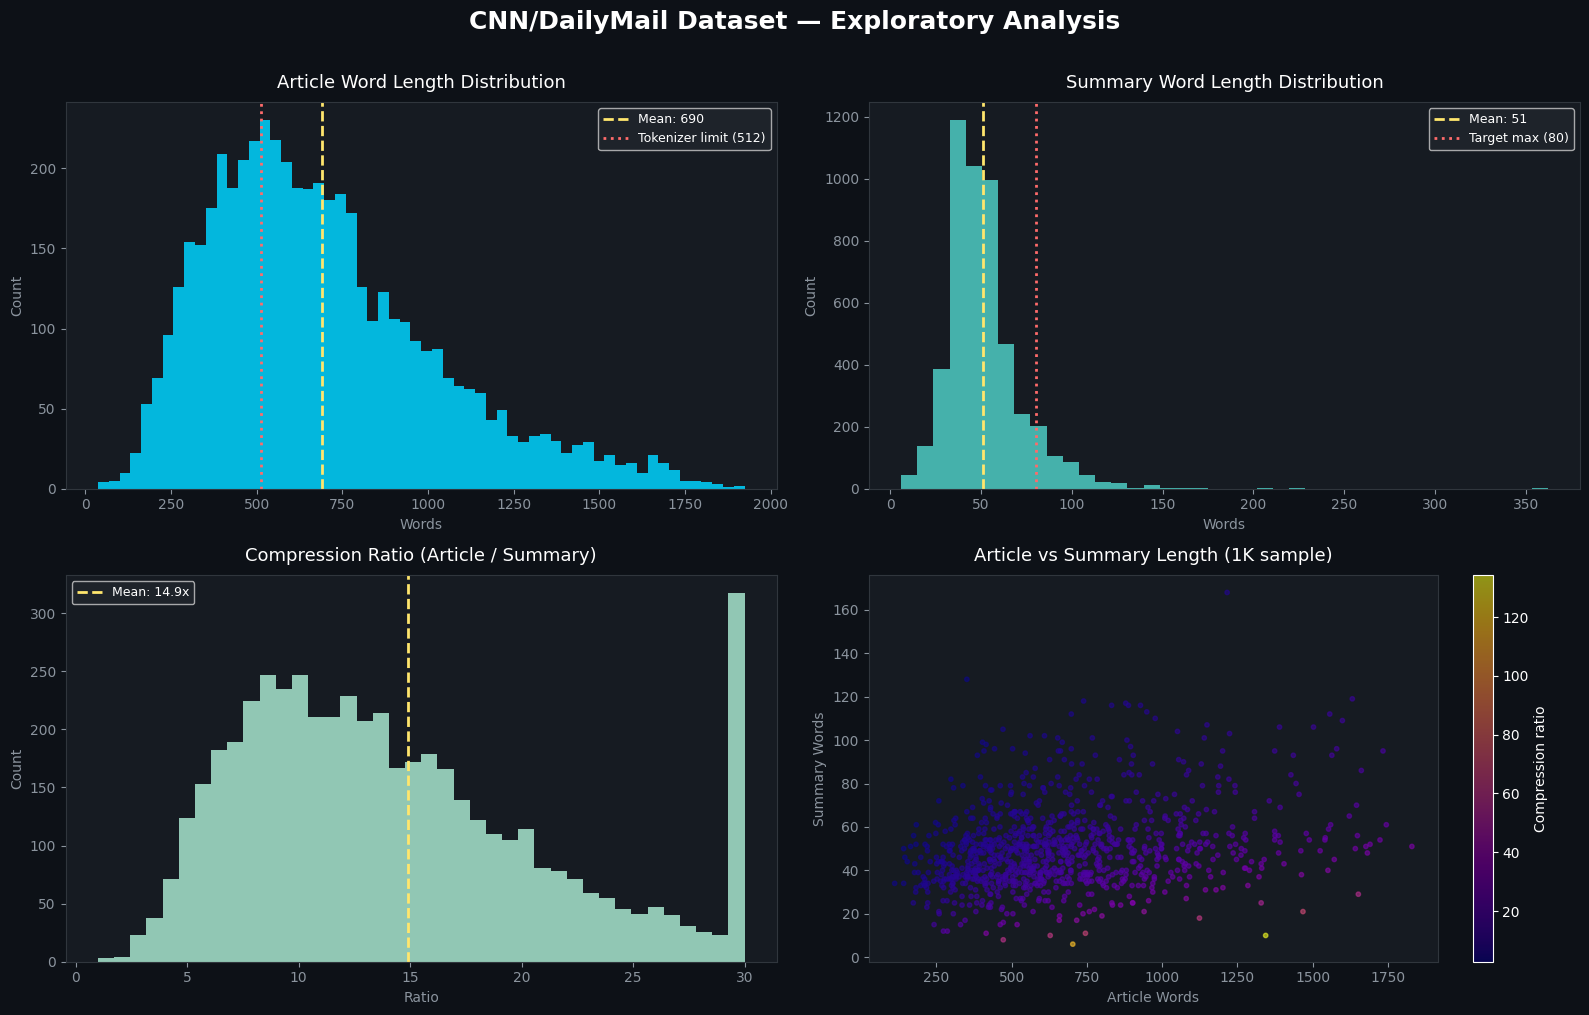

✅ EDA plots saved → /kaggle/working/bart_finetuning/eda_plots.png


In [5]:
print('📊 Computing dataset statistics...')
sample_for_eda = train_raw.select(range(5000))

article_lens = [len(x['article'].split())    for x in sample_for_eda]
summary_lens = [len(x['highlights'].split()) for x in sample_for_eda]
compression  = [a / max(s, 1) for a, s in zip(article_lens, summary_lens)]

stats = pd.DataFrame({
    'Article Words': article_lens,
    'Summary Words': summary_lens,
    'Compression'  : compression,
})
print(stats.describe().round(1))

plt.style.use('dark_background')
PALETTE = ['#00D4FF', '#FF6B6B', '#FFE66D', '#4ECDC4', '#A8E6CF']

fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='#0D1117')
fig.suptitle('CNN/DailyMail Dataset — Exploratory Analysis',
             fontsize=18, fontweight='bold', color='white', y=1.01)

for ax in axes.flat:
    ax.set_facecolor('#161B22')
    ax.tick_params(colors='#8B949E')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363D')

ax = axes[0, 0]
ax.hist(article_lens, bins=60, color=PALETTE[0], alpha=0.85, edgecolor='none')
ax.axvline(np.mean(article_lens), color=PALETTE[2], lw=2, ls='--',
           label=f'Mean: {np.mean(article_lens):.0f}')
ax.axvline(512, color=PALETTE[1], lw=2, ls=':', label='Tokenizer limit (512)')
ax.set_title('Article Word Length Distribution', color='white', fontsize=13, pad=10)
ax.set_xlabel('Words', color='#8B949E'); ax.set_ylabel('Count', color='#8B949E')
ax.legend(fontsize=9, facecolor='#21262D', labelcolor='white')

ax = axes[0, 1]
ax.hist(summary_lens, bins=40, color=PALETTE[3], alpha=0.85, edgecolor='none')
ax.axvline(np.mean(summary_lens), color=PALETTE[2], lw=2, ls='--',
           label=f'Mean: {np.mean(summary_lens):.0f}')
ax.axvline(CFG['gen_max_length'], color=PALETTE[1], lw=2, ls=':',
           label=f"Target max ({CFG['gen_max_length']})")
ax.set_title('Summary Word Length Distribution', color='white', fontsize=13, pad=10)
ax.set_xlabel('Words', color='#8B949E'); ax.set_ylabel('Count', color='#8B949E')
ax.legend(fontsize=9, facecolor='#21262D', labelcolor='white')

ax = axes[1, 0]
clipped = [min(c, 30) for c in compression]
ax.hist(clipped, bins=40, color=PALETTE[4], alpha=0.85, edgecolor='none')
ax.axvline(np.mean(compression), color=PALETTE[2], lw=2, ls='--',
           label=f'Mean: {np.mean(compression):.1f}x')
ax.set_title('Compression Ratio (Article / Summary)', color='white', fontsize=13, pad=10)
ax.set_xlabel('Ratio', color='#8B949E'); ax.set_ylabel('Count', color='#8B949E')
ax.legend(fontsize=9, facecolor='#21262D', labelcolor='white')

ax = axes[1, 1]
sample_idx = np.random.choice(len(article_lens), 1000, replace=False)
sc = ax.scatter([article_lens[i] for i in sample_idx],
                [summary_lens[i] for i in sample_idx],
                c=[compression[i] for i in sample_idx],
                cmap='plasma', alpha=0.6, s=10)
plt.colorbar(sc, ax=ax, label='Compression ratio').ax.yaxis.label.set_color('white')
ax.set_title('Article vs Summary Length (1K sample)', color='white', fontsize=13, pad=10)
ax.set_xlabel('Article Words', color='#8B949E'); ax.set_ylabel('Summary Words', color='#8B949E')

plt.tight_layout()
eda_path = os.path.join(BASE_DIR, 'eda_plots.png')
plt.savefig(eda_path, dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print(f'✅ EDA plots saved → {eda_path}')

## Cell 5 — Tokenizer & Dataset Class

In [6]:
print(f'🔤 Loading tokenizer: {CFG["model_name"]}')
tokenizer = BartTokenizer.from_pretrained(CFG['model_name'])
print(f'   Vocab size : {tokenizer.vocab_size:,}')

class NewsDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_input, max_target):
        self.data       = hf_dataset
        self.tokenizer  = tokenizer
        self.max_input  = max_input
        self.max_target = max_target

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row     = self.data[idx]
        article = row['article'].strip()
        summary = row['highlights'].strip()
        # Tokenize input article
        encoding = self.tokenizer(
            article,
            max_length=self.max_input,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        # Tokenize target summary separately (fixes 'max_target_length not recognized' warning)
        with self.tokenizer.as_target_tokenizer():
            target_encoding = self.tokenizer(
                summary,
                max_length=self.max_target,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
        labels = target_encoding['input_ids'].squeeze().clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'labels'         : labels,
        }

train_ds = NewsDataset(train_raw, tokenizer, CFG['max_input_length'], CFG['max_target_length'])
val_ds   = NewsDataset(val_raw,   tokenizer, CFG['max_input_length'], CFG['max_target_length'])
test_ds  = NewsDataset(test_raw,  tokenizer, CFG['max_input_length'], CFG['max_target_length'])

train_loader = DataLoader(train_ds, batch_size=CFG['train_batch_size'],
                          shuffle=True,  num_workers=2, pin_memory=True,
                          persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['eval_batch_size'],
                          shuffle=False, num_workers=2, pin_memory=True,
                          persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['eval_batch_size'],
                          shuffle=False, num_workers=2, pin_memory=True,
                          persistent_workers=True)

print(f'\n✅ Datasets ready')
print(f'   Train batches : {len(train_loader):,}')
print(f'   Val batches   : {len(val_loader):,}')
print(f'   Test batches  : {len(test_loader):,}')
print_space_status('(after dataset class)')


🔤 Loading tokenizer: facebook/bart-large-cnn


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

   Vocab size : 50,265

✅ Datasets ready
   Train batches : 22,500
   Val batches   : 625
   Test batches  : 625
🟢 Disk [███░░░░░░░░░░░░░░░░░░░░░░░░░░░] 2.2/20 GB used  |  18.7 GB free  (after dataset class)


## Cell 6 — Load Model & Optimizer

In [7]:
# ── Clear GPU memory before loading ───────────────────────────────────────
for _var in ['model', 'optimizer', 'scheduler', 'scaler']:
    try:
        del globals()[_var]
    except KeyError:
        pass
clear_gpu_cache()
print(f'GPU cleared. Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB')

# ── Detect best available checkpoint ──────────────────────────────────────
def find_best_checkpoint():
    ckpt_dir = CFG['checkpoint_dir']
    _best  = os.path.join(ckpt_dir, 'ckpt_best.pt')
    if os.path.exists(_best):
        return _best
    _steps = sorted(glob.glob(os.path.join(ckpt_dir, 'ckpt_step_*.pt')),
                    key=os.path.getmtime)
    if _steps:
        return _steps[-1]
    _epochs = sorted(glob.glob(os.path.join(ckpt_dir, 'ckpt_epoch_*.pt')),
                     key=os.path.getmtime)
    return _epochs[-1] if _epochs else None

_resume_path = find_best_checkpoint()

# ── Load model on CPU first, move to GPU after weights are set ─────────────
print(f'\n🤖 Loading model: {CFG["model_name"]}')
model = BartForConditionalGeneration.from_pretrained(CFG['model_name'])
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'   Total params    : {total_params/1e6:.1f}M')
print(f'   Trainable params: {trainable_params/1e6:.1f}M')

# ── Optimizer ─────────────────────────────────────────────────────────────
no_decay   = ['bias', 'LayerNorm.weight']
opt_groups = [
    {'params': [p for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay)], 'weight_decay': CFG['weight_decay']},
    {'params': [p for n, p in model.named_parameters()
                if any(nd in n for nd in no_decay)],     'weight_decay': 0.0},
]
optimizer = AdamW(opt_groups, lr=CFG['learning_rate'])

# ── Scheduler ─────────────────────────────────────────────────────────────
total_steps  = (len(train_loader) // CFG['grad_accum_steps']) * CFG['epochs']
warmup_steps = int(total_steps * CFG['warmup_ratio'])
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

# ── Scaler ─────────────────────────────────────────────────────────────────
if CFG['fp16']:
    try:
        scaler = GradScaler(device='cuda')
    except TypeError:
        scaler = GradScaler()
else:
    scaler = None

# ── Load checkpoint if available (CPU-first to avoid OOM) ─────────────────
if _resume_path:
    print(f'\n🔄 Resuming from: {os.path.basename(_resume_path)}')
    _ckpt = torch.load(_resume_path, map_location='cpu', weights_only=False)
    # Handle fp16-saved checkpoints
    if CFG.get('save_fp16_ckpt'):
        _state = {k: v.float() if v.dtype == torch.float16 else v
                  for k, v in _ckpt['model'].items()}
    else:
        _state = _ckpt['model']
    model.load_state_dict(_state)
    del _state
    if 'optimizer' in _ckpt and _ckpt['optimizer'] is not None:
        optimizer.load_state_dict(_ckpt['optimizer'])
    if 'scheduler' in _ckpt and _ckpt['scheduler'] is not None:
        scheduler.load_state_dict(_ckpt['scheduler'])
    if 'scaler' in _ckpt and scaler is not None and _ckpt['scaler'] is not None:
        scaler.load_state_dict(_ckpt['scaler'])
    _resume_epoch = _ckpt.get('epoch', 0)
    _resume_step  = _ckpt.get('step',  0)
    _resume_rouge = _ckpt.get('best_rouge', 0.0)
    _resume_hist  = _ckpt.get('history', None)
    del _ckpt
    gc.collect()
    print(f'   Resumed epoch {_resume_epoch}, step {_resume_step:,}, best ROUGE-1 {_resume_rouge:.2f}')
else:
    _resume_epoch = None
    _resume_step  = 0
    _resume_rouge = 0.0
    _resume_hist  = None
    print('\n🆕 No checkpoint — starting from scratch.')

model = model.to(DEVICE)
print(f'\n✅ Model on {DEVICE} | {gpu_info()}')
print(f'   Total steps  : {total_steps:,}  |  Warmup steps : {warmup_steps:,}')
print_space_status('(after model load)')

GPU cleared. Allocated: 0.00 GB

🤖 Loading model: facebook/bart-large-cnn


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

   Total params    : 406.3M
   Trainable params: 406.3M

🆕 No checkpoint — starting from scratch.

✅ Model on cuda | GPU 1.6/15.6 GB alloc | 1.6 GB reserved
   Total steps  : 16,875  |  Warmup steps : 843
🟢 Disk [█████░░░░░░░░░░░░░░░░░░░░░░░░░] 3.8/20 GB used  |  17.1 GB free  (after model load)


## Cell 7 — Checkpoint & Evaluation Utilities (Space-Aware)

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# DISK-SPACE-AWARE CHECKPOINT UTILITIES
# ═══════════════════════════════════════════════════════════════════════════

def check_disk_space(min_gb=None, path=None):
    """Raise RuntimeError if free space < threshold. Returns free GB."""
    if min_gb is None:
        min_gb = CFG['min_free_gb']
    free = disk_free_gb(path or '/kaggle/working')
    if free < min_gb:
        raise RuntimeError(
            f'Only {free:.1f} GB free (need {min_gb} GB) — checkpoint skipped.'
        )
    return free

def _model_state_to_save(model):
    """Return model state dict, optionally in fp16 to halve checkpoint size."""
    state = model.state_dict()
    if CFG.get('save_fp16_ckpt'):
        state = {k: v.half() for k, v in state.items()}
    return state

def _prune_step_checkpoints():
    """Delete old step checkpoints, keeping only keep_last_n."""
    pattern   = os.path.join(CFG['checkpoint_dir'], 'ckpt_step_*.pt')
    all_steps = sorted(glob.glob(pattern), key=os.path.getmtime)
    for old in all_steps[:-CFG['keep_last_n']]:
        try:
            os.remove(old)
            print(f'   🗑️  Removed {os.path.basename(old)}')
        except Exception as e:
            print(f'   ⚠️  Could not remove {os.path.basename(old)}: {e}')

def save_checkpoint(model, optimizer, scheduler, scaler, epoch, step,
                    val_loss, best_rouge, history, label='step'):
    """
    Space-efficient checkpoint saving:
      'step'    → model (fp16) + full optimizer state; keep_last_n enforced
      'best'    → model (fp16) only; never pruned
      'epoch_N' → model (fp16) only; no optimizer (lightweight)

    Optimizer state (~4 GB) is only kept in step checkpoints so
    training can resume exactly. Best and epoch checkpoints skip it
    to save ~4 GB per checkpoint.
    """
    # ── Pre-save: delete old step ckpts BEFORE writing new one ────────────
    # This avoids the brief moment where both old and new exist simultaneously
    if label == 'step':
        _prune_step_checkpoints()

    free_gb = check_disk_space()  # raises RuntimeError if too full

    is_step  = (label == 'step')
    filename = f'ckpt_{label}_{step}.pt' if is_step else f'ckpt_{label}.pt'
    path     = os.path.join(CFG['checkpoint_dir'], filename)

    # ── Payload — full optimizer only for step checkpoints ─────────────────
    if is_step:
        payload = {
            'epoch'     : epoch,
            'step'      : step,
            'model'     : _model_state_to_save(model),
            'optimizer' : optimizer.state_dict(),
            'scheduler' : scheduler.state_dict(),
            'scaler'    : scaler.state_dict() if scaler is not None else None,
            'val_loss'  : val_loss,
            'best_rouge': best_rouge,
            'history'   : history,
        }
    else:
        # Lightweight: model weights + metadata only (~0.8 GB in fp16)
        payload = {
            'epoch'     : epoch,
            'step'      : step,
            'model'     : _model_state_to_save(model),
            'optimizer' : None,   # deliberately omitted
            'scheduler' : None,
            'scaler'    : None,
            'val_loss'  : val_loss,
            'best_rouge': best_rouge,
            'history'   : history,
        }

    torch.save(payload, path)
    ckpt_gb = os.path.getsize(path) / 1e9
    print(f'   💾 Saved {filename} ({ckpt_gb:.2f} GB)  |  {disk_free_gb():.1f} GB remaining')
    return path

# ═══════════════════════════════════════════════════════════════════════════
# ROUGE EVALUATION
# ═══════════════════════════════════════════════════════════════════════════
rouge_metric = evaluate.load('rouge')

def _autocast():
    if not CFG['fp16'] or not torch.cuda.is_available():
        import contextlib
        return contextlib.nullcontext()
    try:
        return autocast(device_type='cuda')
    except TypeError:
        return autocast(enabled=True)

def evaluate_rouge(model, loader, tokenizer, num_batches=50):
    model.eval()
    preds, refs = [], []
    with torch.no_grad():
        for i, batch in enumerate(tqdm(loader, desc='ROUGE eval', leave=False)):
            if i >= num_batches:
                break
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels']
            with _autocast():
                generated = model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    max_length=CFG['gen_max_length'],
                    min_length=CFG['gen_min_length'],
                    num_beams=CFG['num_beams'],
                    length_penalty=CFG['length_penalty'],
                    early_stopping=CFG['early_stopping'],
                    no_repeat_ngram_size=CFG['no_repeat_ngram'],
                )
            decoded_preds  = tokenizer.batch_decode(generated, skip_special_tokens=True)
            labels_clean   = labels.clone()
            labels_clean[labels_clean == -100] = tokenizer.pad_token_id
            decoded_labels = tokenizer.batch_decode(labels_clean, skip_special_tokens=True)
            preds.extend(decoded_preds)
            refs.extend(decoded_labels)
    result = rouge_metric.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: round(v * 100, 4) for k, v in result.items()}

print('✅ Checkpoint & evaluation utilities defined')
print(f'   Disk free : {disk_free_gb():.1f} GB  |  FP16 checkpoints : {CFG["save_fp16_ckpt"]}')
print(f'   Step ckpts kept   : {CFG["keep_last_n"]}  (old ones deleted BEFORE saving new)')

✅ Checkpoint & evaluation utilities defined
   Disk free : 17.1 GB  |  FP16 checkpoints : True
   Step ckpts kept   : 1  (old ones deleted BEFORE saving new)


## Cell 8 — Pre-Training Baseline (Zero-Shot ROUGE)

In [9]:
print('📏 Computing ZERO-SHOT baseline ROUGE (25 batches × 8 = 200 samples)...')
baseline_rouge = evaluate_rouge(model, val_loader, tokenizer, num_batches=25)

print('\n' + '─'*40)
print('BASELINE (zero-shot) ROUGE Scores:')
print('─'*40)
for k, v in baseline_rouge.items():
    print(f'  {k:12s}: {v:.2f}')
print('─'*40)
print('NOTE: Already high — BART was pre-trained on CNN/DailyMail.')

📏 Computing ZERO-SHOT baseline ROUGE (25 batches × 8 = 200 samples)...


ROUGE eval:   0%|          | 0/625 [00:00<?, ?it/s]


────────────────────────────────────────
BASELINE (zero-shot) ROUGE Scores:
────────────────────────────────────────
  rouge1      : 43.58
  rouge2      : 21.04
  rougeL      : 31.15
  rougeLsum   : 37.18
────────────────────────────────────────
NOTE: Already high — BART was pre-trained on CNN/DailyMail.


## Cell 9 — Training Loop with Space-Aware Checkpointing

In [10]:
# ── Restore state from Cell 6 checkpoint detection ────────────────────────
if _resume_epoch is not None:
    start_epoch = _resume_epoch + 1
    global_step = _resume_step
    best_rouge1 = _resume_rouge
    history     = _resume_hist if _resume_hist is not None else {
        'train_loss': [], 'val_loss': [],
        'rouge1': [], 'rouge2': [], 'rougeL': [],
        'lr': [], 'step_losses': []
    }
    print(f'🔄 Resuming from epoch {start_epoch + 1} / {CFG["epochs"]}')
    print(f'   Global step  : {global_step:,}  |  Best ROUGE-1 : {best_rouge1:.2f}')
else:
    history = {
        'train_loss': [], 'val_loss': [],
        'rouge1': [], 'rouge2': [], 'rougeL': [],
        'lr': [], 'step_losses': []
    }
    best_rouge1 = 0.0
    global_step = 0
    start_epoch = 0
    print('🆕 Starting training from scratch.')

if start_epoch >= CFG['epochs']:
    print(f'\n✅ All {CFG["epochs"]} epochs complete — nothing to do.')

print_space_status('(before training loop)')

print(f'\n🚀 Fine-tuning | {CFG["epochs"]} epochs | {len(train_loader):,} batches/epoch')
print(f'   Effective batch : {CFG["train_batch_size"] * CFG["grad_accum_steps"]}  |  FP16: {CFG["fp16"]}')
print(f'   Ckpt every      : {CFG["save_every_steps"]} steps  |  keep_last_n: {CFG["keep_last_n"]}')
print(f'   FP16 checkpoints: {CFG["save_fp16_ckpt"]} (~0.8 GB each vs ~1.6 GB)')
print(f'   Min free GB     : {CFG["min_free_gb"]}\n')

training_start = time.time()
current_lr     = CFG['learning_rate']

for epoch in range(start_epoch, CFG['epochs']):
    model.train()
    epoch_loss   = 0.0
    batch_losses = []
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{CFG["epochs"]}',
                ncols=120, leave=True)

    for batch_idx, batch in enumerate(pbar):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        with _autocast():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss    = outputs.loss / CFG['grad_accum_steps']

        if scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if (batch_idx + 1) % CFG['grad_accum_steps'] == 0:
            if scaler is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['max_grad_norm'])
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['max_grad_norm'])
                optimizer.step()

            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

            step_loss  = loss.item() * CFG['grad_accum_steps']
            epoch_loss += step_loss
            batch_losses.append(step_loss)
            history['step_losses'].append(step_loss)
            current_lr = scheduler.get_last_lr()[0]

            free_gb = disk_free_gb()
            pbar.set_postfix({
                'loss': f'{step_loss:.4f}',
                'lr'  : f'{current_lr:.2e}',
                'step': global_step,
                'free': f'{free_gb:.1f}GB',
            })

            # ── Step checkpoint ─────────────────────────────────────────────
            if global_step % CFG['save_every_steps'] == 0:
                try:
                    print(f'\n[Step {global_step}] Saving step checkpoint...')
                    save_checkpoint(
                        model, optimizer, scheduler, scaler,
                        epoch, global_step, step_loss, best_rouge1, history, label='step'
                    )
                except RuntimeError as e:
                    print(f'\n⚠️  {e}')
                    print('   Training continues; checkpoint skipped.')

    # ── End-of-epoch evaluation ────────────────────────────────────────────
    avg_train_loss = epoch_loss / max(len(batch_losses), 1)

    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Val loss', leave=False):
            inp = batch['input_ids'].to(DEVICE)
            msk = batch['attention_mask'].to(DEVICE)
            lbl = batch['labels'].to(DEVICE)
            with _autocast():
                out = model(input_ids=inp, attention_mask=msk, labels=lbl)
            val_losses.append(out.loss.item())
    avg_val_loss = float(np.mean(val_losses))

    print(f'\n[Epoch {epoch+1}] Computing ROUGE...')
    rouge_scores = evaluate_rouge(model, val_loader, tokenizer, num_batches=50)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['rouge1'].append(rouge_scores['rouge1'])
    history['rouge2'].append(rouge_scores['rouge2'])
    history['rougeL'].append(rouge_scores['rougeL'])
    history['lr'].append(current_lr)

    elapsed = (time.time() - training_start) / 60
    print(f'\n{"="*60}')
    print(f'EPOCH {epoch+1} SUMMARY  |  Elapsed: {elapsed:.1f} min')
    print(f'  Train Loss : {avg_train_loss:.4f}')
    print(f'  Val Loss   : {avg_val_loss:.4f}')
    print(f'  ROUGE-1    : {rouge_scores["rouge1"]:.2f}')
    print(f'  ROUGE-2    : {rouge_scores["rouge2"]:.2f}')
    print(f'  ROUGE-L    : {rouge_scores["rougeL"]:.2f}')
    print_space_status(f'(end of epoch {epoch+1})')
    if DEVICE.type == 'cuda':
        print(f'  {gpu_info()}')
    print(f'{"="*60}')

    # ── Save best model ────────────────────────────────────────────────────
    if rouge_scores['rouge1'] > best_rouge1:
        best_rouge1 = rouge_scores['rouge1']
        try:
            # Best checkpoint: model weights only (no optimizer) → ~0.8 GB
            save_checkpoint(
                model, optimizer, scheduler, scaler,
                epoch, global_step, avg_val_loss, best_rouge1, history, label='best'
            )
            # Also save tokenizer & model in HF format for easy loading
            model.save_pretrained(CFG['output_dir'])
            tokenizer.save_pretrained(CFG['output_dir'])
            print(f'   🏆 Best model saved! ROUGE-1: {best_rouge1:.2f}')
        except RuntimeError as e:
            print(f'\n⚠️  Could not save best model: {e}')

    # ── Lightweight epoch checkpoint (model only, no optimizer) ───────────
    try:
        save_checkpoint(
            model, optimizer, scheduler, scaler,
            epoch, global_step, avg_val_loss, best_rouge1,
            history, label=f'epoch_{epoch+1}'
        )
    except RuntimeError as e:
        print(f'\n⚠️  Epoch checkpoint skipped: {e}')

    # ── Post-epoch cleanup ─────────────────────────────────────────────────
    clear_gpu_cache()

total_time = (time.time() - training_start) / 60
print(f'\n✅ Training complete in {total_time:.1f} minutes')
print(f'   Best ROUGE-1: {best_rouge1:.2f}')
print_space_status('(training done)')

🆕 Starting training from scratch.
🟢 Disk [█████░░░░░░░░░░░░░░░░░░░░░░░░░] 3.8/20 GB used  |  17.1 GB free  (before training loop)

🚀 Fine-tuning | 3 epochs | 22,500 batches/epoch
   Effective batch : 16  |  FP16: True
   Ckpt every      : 500 steps  |  keep_last_n: 1
   FP16 checkpoints: True (~0.8 GB each vs ~1.6 GB)
   Min free GB     : 3.0



Epoch 1/3:   0%|                                                                              | 0/22500 [00:00…


[Step 500] Saving step checkpoint...
   💾 Saved ckpt_step_500.pt (4.37 GB)  |  12.7 GB remaining

[Step 1000] Saving step checkpoint...
   💾 Saved ckpt_step_1000.pt (4.37 GB)  |  8.4 GB remaining

[Step 1500] Saving step checkpoint...
   🗑️  Removed ckpt_step_500.pt
   💾 Saved ckpt_step_1500.pt (4.37 GB)  |  8.4 GB remaining

[Step 2000] Saving step checkpoint...
   🗑️  Removed ckpt_step_1000.pt
   💾 Saved ckpt_step_2000.pt (4.37 GB)  |  8.4 GB remaining

[Step 2500] Saving step checkpoint...
   🗑️  Removed ckpt_step_1500.pt
   💾 Saved ckpt_step_2500.pt (4.37 GB)  |  8.4 GB remaining

[Step 3000] Saving step checkpoint...
   🗑️  Removed ckpt_step_2000.pt
   💾 Saved ckpt_step_3000.pt (4.37 GB)  |  8.4 GB remaining

[Step 3500] Saving step checkpoint...
   🗑️  Removed ckpt_step_2500.pt
   💾 Saved ckpt_step_3500.pt (4.37 GB)  |  8.4 GB remaining

[Step 4000] Saving step checkpoint...
   🗑️  Removed ckpt_step_3000.pt
   💾 Saved ckpt_step_4000.pt (4.37 GB)  |  8.4 GB remaining

[Step 4500]

Val loss:   0%|          | 0/625 [00:00<?, ?it/s]


[Epoch 1] Computing ROUGE...


...


[Epoch 3] Computing ROUGE...


ROUGE eval:   0%|          | 0/625 [00:00<?, ?it/s]


EPOCH 3 SUMMARY  |  Elapsed: 360.6 min
  Train Loss : 1.0415
  Val Loss   : 1.6024
  ROUGE-1    : 45.32
  ROUGE-2    : 22.13
  ROUGE-L    : 31.80
🟡 Disk [██████████████████████████░░░░] 17.6/20 GB used  |  3.4 GB free  (end of epoch 3)
  GPU 5.2/15.6 GB alloc | 10.1 GB reserved


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0, 'forced_eos_token_id': 2}


   💾 Saved ckpt_best.pt (1.12 GB)  |  3.4 GB remaining
   🏆 Best model saved! ROUGE-1: 45.32
   💾 Saved ckpt_epoch_3.pt (1.12 GB)  |  2.2 GB remaining

✅ Training complete in 360.8 minutes
   Best ROUGE-1: 45.32
🔴 Disk [████████████████████████████░░] 18.7/20 GB used  |  2.2 GB free  (training done)


## Cell 9b — Emergency Space Recovery (Run if You're Near the 20 GB Limit)
Only run this if you're worried about disk space. It deletes old caches and step checkpoints.

In [11]:
# # ══════════════════════════════════════════════════════════════════════════
# # EMERGENCY SPACE RECOVERY
# # Run this cell if training stopped due to disk space issues.
# # It safely removes large files while keeping the best checkpoint.
# # ══════════════════════════════════════════════════════════════════════════

# import shutil
# 9
# print('🧹 Space recovery scan...')
# print_space_status('(before recovery)')

# freed_total = 0.0

# # 1. Remove all step checkpoints except the very latest
# step_ckpts = sorted(glob.glob(os.path.join(CKPT_DIR, 'ckpt_step_*.pt')),
#                     key=os.path.getmtime)
# for old in step_ckpts[:-1]:  # keep only the last one
#     size_gb = os.path.getsize(old) / 1e9
#     os.remove(old)
#     freed_total += size_gb
#     print(f'   🗑️  Removed step ckpt: {os.path.basename(old)}  ({size_gb:.2f} GB)')

# # 2. Remove epoch checkpoints if best checkpoint exists
# best_ckpt_path = os.path.join(CKPT_DIR, 'ckpt_best.pt')
# if os.path.exists(best_ckpt_path):
#     for ep_ckpt in glob.glob(os.path.join(CKPT_DIR, 'ckpt_epoch_*.pt')):
#         size_gb = os.path.getsize(ep_ckpt) / 1e9
#         os.remove(ep_ckpt)
#         freed_total += size_gb
#         print(f'   🗑️  Removed epoch ckpt: {os.path.basename(ep_ckpt)}  ({size_gb:.2f} GB)')
# else:
#     print('   ℹ️  No best checkpoint found — keeping epoch checkpoints as fallback.')

# # 3. Wipe HuggingFace model download cache (the model is already loaded in memory)
# # WARNING: only do this if model is loaded; you'll need internet to re-download
# hf_models_cache = os.path.join(HF_CACHE, 'hub')
# if os.path.exists(hf_models_cache):
#     size_gb = sum(os.path.getsize(os.path.join(dp, f))
#                   for dp, dn, fn in os.walk(hf_models_cache) for f in fn) / 1e9
#     print(f'\n   HF hub cache size: {size_gb:.2f} GB')
#     ans = input('   Delete HF model cache? (yes/no): ').strip().lower()
#     if ans == 'yes':
#         shutil.rmtree(hf_models_cache)
#         freed_total += size_gb
#         print(f'   🗑️  Deleted HF hub cache ({size_gb:.2f} GB)')
#         print('   ⚠️  Note: you will need internet access to reload the base model.')

# print(f'\n✅ Freed ~{freed_total:.2f} GB total')
# print_space_status('(after recovery)')

🧹 Space recovery scan...
🔴 Disk [████████████████████████████░░] 18.7/20 GB used  |  2.2 GB free  (before recovery)
   🗑️  Removed step ckpt: ckpt_step_16000.pt  (4.37 GB)
   🗑️  Removed epoch ckpt: ckpt_epoch_2.pt  (1.12 GB)
   🗑️  Removed epoch ckpt: ckpt_epoch_1.pt  (1.12 GB)
   🗑️  Removed epoch ckpt: ckpt_epoch_3.pt  (1.12 GB)

✅ Freed ~7.74 GB total
🟢 Disk [████████████████░░░░░░░░░░░░░░] 11.0/20 GB used  |  10.0 GB free  (after recovery)


## Cell 10 — Training Curves

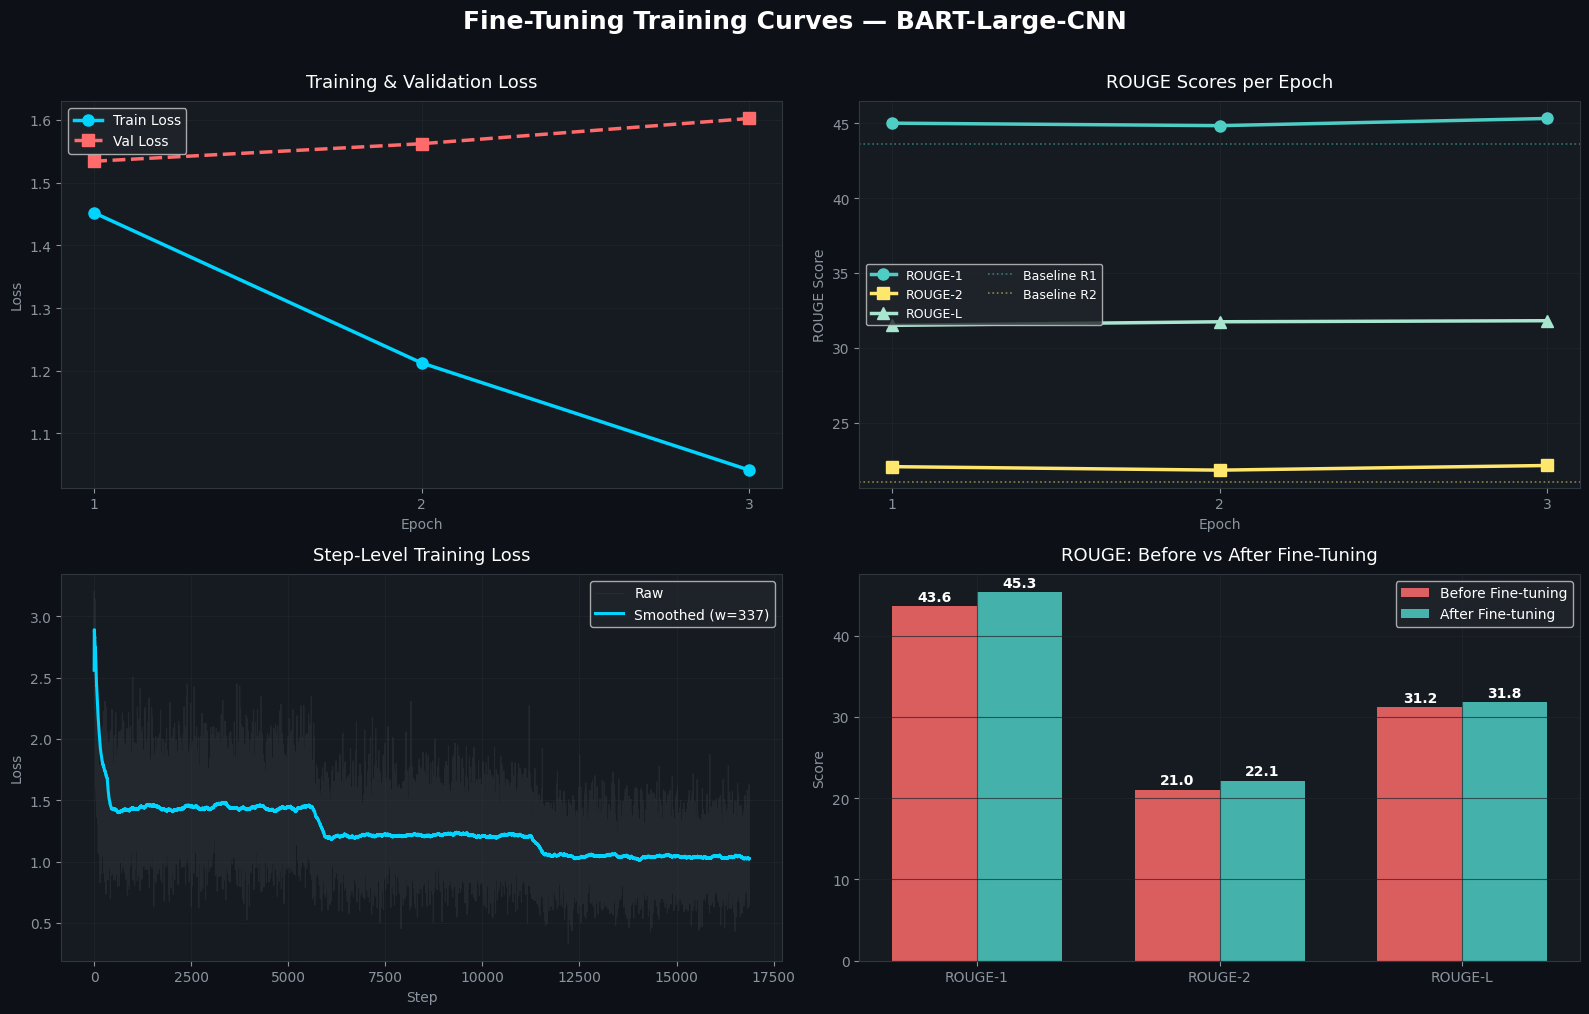

✅ Training curves saved → /kaggle/working/bart_finetuning/training_curves.png


In [12]:
epochs_x = list(range(1, len(history['train_loss']) + 1))

plt.style.use('dark_background')
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='#0D1117')
fig.suptitle('Fine-Tuning Training Curves — BART-Large-CNN',
             fontsize=18, fontweight='bold', color='white', y=1.01)

for ax in axes.flat:
    ax.set_facecolor('#161B22')
    ax.tick_params(colors='#8B949E')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363D')
    ax.grid(True, color='#21262D', lw=0.8, alpha=0.7)

ax = axes[0, 0]
ax.plot(epochs_x, history['train_loss'], 'o-', color='#00D4FF', lw=2.5, ms=8, label='Train Loss')
ax.plot(epochs_x, history['val_loss'],   's--',color='#FF6B6B', lw=2.5, ms=8, label='Val Loss')
ax.set_title('Training & Validation Loss', color='white', fontsize=13, pad=10)
ax.set_xlabel('Epoch', color='#8B949E'); ax.set_ylabel('Loss', color='#8B949E')
ax.legend(fontsize=10, facecolor='#21262D', labelcolor='white')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax = axes[0, 1]
ax.plot(epochs_x, history['rouge1'], 'o-', color='#4ECDC4', lw=2.5, ms=8, label='ROUGE-1')
ax.plot(epochs_x, history['rouge2'], 's-', color='#FFE66D', lw=2.5, ms=8, label='ROUGE-2')
ax.plot(epochs_x, history['rougeL'], '^-', color='#A8E6CF', lw=2.5, ms=8, label='ROUGE-L')
if 'baseline_rouge' in dir():
    ax.axhline(baseline_rouge['rouge1'], color='#4ECDC4', lw=1.2, ls=':', alpha=0.5, label='Baseline R1')
    ax.axhline(baseline_rouge['rouge2'], color='#FFE66D', lw=1.2, ls=':', alpha=0.5, label='Baseline R2')
ax.set_title('ROUGE Scores per Epoch', color='white', fontsize=13, pad=10)
ax.set_xlabel('Epoch', color='#8B949E'); ax.set_ylabel('ROUGE Score', color='#8B949E')
ax.legend(fontsize=9, facecolor='#21262D', labelcolor='white', ncol=2)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax = axes[1, 0]
steps_x  = list(range(len(history['step_losses'])))
window   = max(10, len(steps_x)//50)
smoothed = pd.Series(history['step_losses']).rolling(window, min_periods=1).mean().tolist()
ax.plot(steps_x, history['step_losses'], color='#30363D', lw=0.8, alpha=0.5, label='Raw')
ax.plot(steps_x, smoothed,               color='#00D4FF', lw=2.2, label=f'Smoothed (w={window})')
ax.set_title('Step-Level Training Loss', color='white', fontsize=13, pad=10)
ax.set_xlabel('Step', color='#8B949E'); ax.set_ylabel('Loss', color='#8B949E')
ax.legend(fontsize=10, facecolor='#21262D', labelcolor='white')

ax = axes[1, 1]
if 'baseline_rouge' in dir():
    metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
    before  = [baseline_rouge['rouge1'], baseline_rouge['rouge2'], baseline_rouge['rougeL']]
    after   = [history['rouge1'][-1], history['rouge2'][-1], history['rougeL'][-1]]
    x = np.arange(len(metrics)); width = 0.35
    bars1 = ax.bar(x - width/2, before, width, label='Before Fine-tuning', color='#FF6B6B', alpha=0.85, edgecolor='none')
    bars2 = ax.bar(x + width/2, after,  width, label='After Fine-tuning',  color='#4ECDC4', alpha=0.85, edgecolor='none')
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom',
                color='white', fontsize=10, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.legend(fontsize=10, facecolor='#21262D', labelcolor='white')
else:
    ax.text(0.5, 0.5, 'Run Cell 8 (baseline) for comparison',
            ha='center', va='center', transform=ax.transAxes, color='#8B949E')
ax.set_title('ROUGE: Before vs After Fine-Tuning', color='white', fontsize=13, pad=10)
ax.set_ylabel('Score', color='#8B949E')

plt.tight_layout()
curves_path = os.path.join(BASE_DIR, 'training_curves.png')
plt.savefig(curves_path, dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print(f'✅ Training curves saved → {curves_path}')

## Cell 11 — Final Test Set Evaluation

In [13]:
print('📥 Loading best model for final test evaluation...')
# Load from saved HF directory (avoids re-downloading from HuggingFace)
best_model = BartForConditionalGeneration.from_pretrained(
    CFG['output_dir'], local_files_only=True
).to(DEVICE)

print('🔍 Evaluating on test set (100 batches)...')
test_rouge = evaluate_rouge(best_model, test_loader, tokenizer, num_batches=100)

_bl = baseline_rouge if 'baseline_rouge' in dir() else {'rouge1':0,'rouge2':0,'rougeL':0,'rougeLsum':0}
results_df = pd.DataFrame({
    'Metric'    : ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'ROUGE-Lsum'],
    'Baseline'  : [_bl.get('rouge1',0), _bl.get('rouge2',0), _bl.get('rougeL',0), _bl.get('rougeLsum',0)],
    'Fine-tuned': [test_rouge.get('rouge1',0), test_rouge.get('rouge2',0),
                   test_rouge.get('rougeL',0), test_rouge.get('rougeLsum',0)],
})
results_df['Improvement'] = (results_df['Fine-tuned'] - results_df['Baseline']).round(2)
results_df['Improvement'] = results_df['Improvement'].apply(lambda x: f'+{x:.2f}' if x >= 0 else f'{x:.2f}')

print('\n' + '='*55)
print('FINAL TEST SET RESULTS')
print('='*55)
print(results_df.to_string(index=False))
print('='*55)

results_path = os.path.join(BASE_DIR, 'final_results.json')
with open(results_path, 'w') as f:
    json.dump({'baseline': _bl, 'finetuned': test_rouge, 'history': history}, f, indent=2)
print(f'\n✅ Results saved → {results_path}')
print_space_status('(after test eval)')

📥 Loading best model for final test evaluation...
🔍 Evaluating on test set (100 batches)...


ROUGE eval:   0%|          | 0/625 [00:00<?, ?it/s]


FINAL TEST SET RESULTS
    Metric  Baseline  Fine-tuned Improvement
   ROUGE-1   43.5839     44.1031       +0.52
   ROUGE-2   21.0365     20.6161       -0.42
   ROUGE-L   31.1520     30.4566       -0.70
ROUGE-Lsum   37.1829     41.0390       +3.86

✅ Results saved → /kaggle/working/bart_finetuning/final_results.json
🟢 Disk [████████████████░░░░░░░░░░░░░░] 11.0/20 GB used  |  10.0 GB free  (after test eval)


## Cell 12 — Summary Quality Analysis Plots

🔄 Generating sample summaries for quality analysis...


Generating:   0%|          | 0/13 [00:00<?, ?it/s]

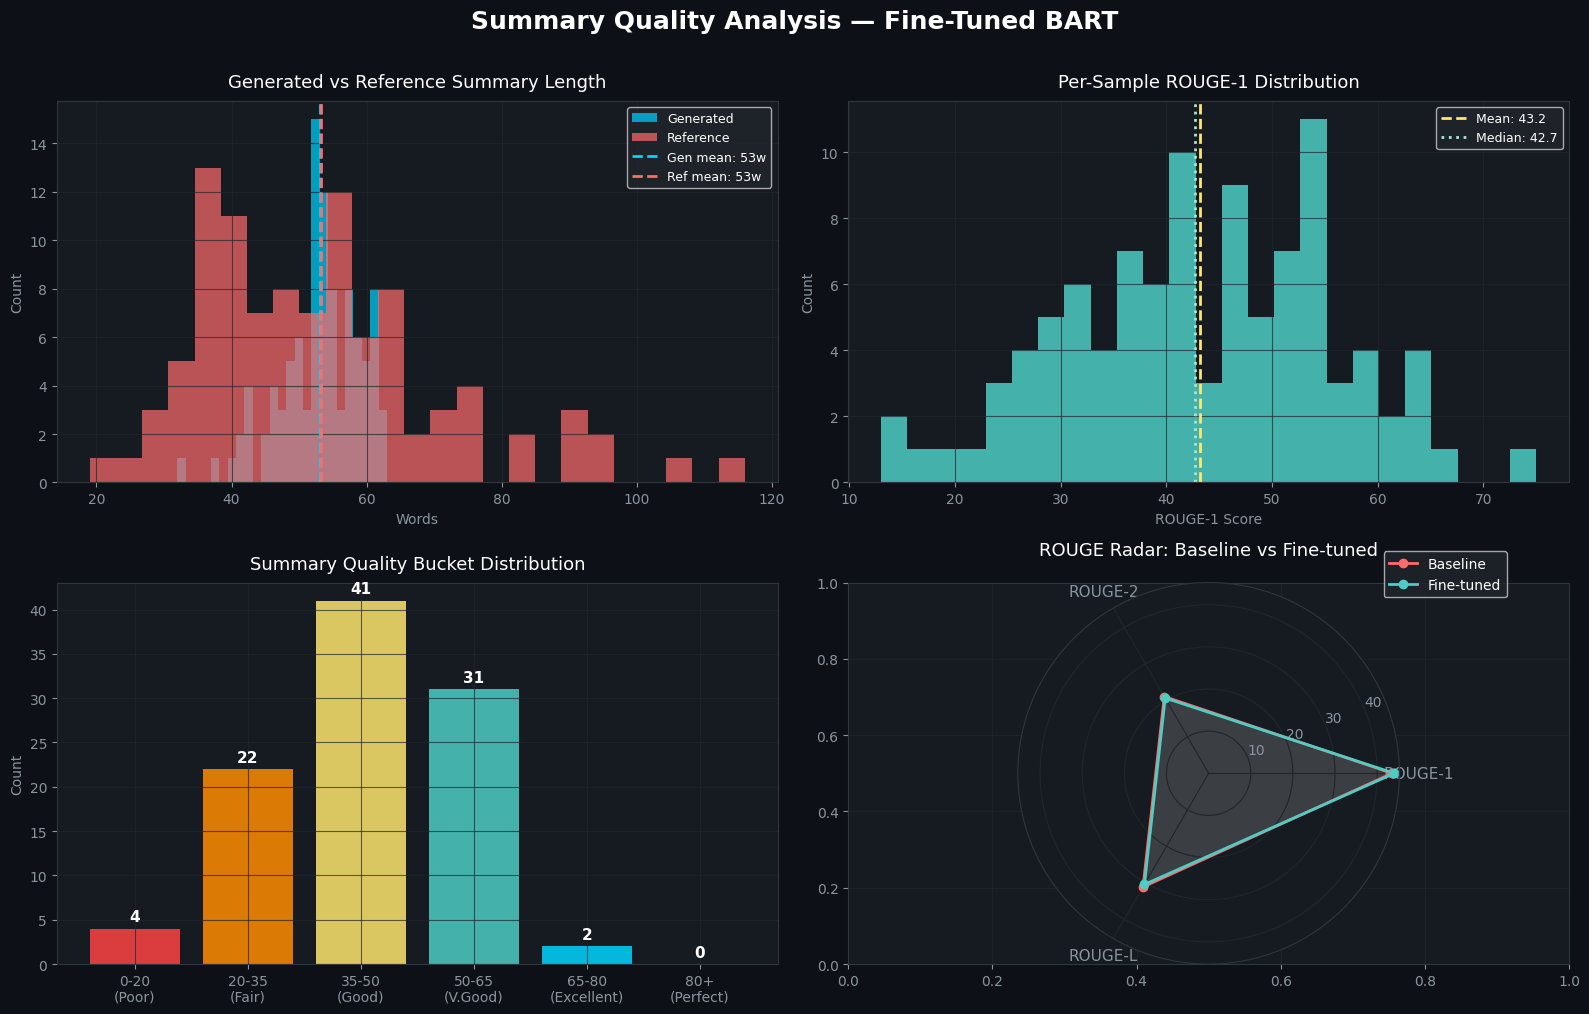

✅ Quality analysis plots saved → /kaggle/working/bart_finetuning/quality_analysis.png


In [15]:
print('🔄 Generating sample summaries for quality analysis...')
best_model.eval()

sample_articles = [test_raw[i]['article']    for i in range(100)]
sample_refs     = [test_raw[i]['highlights'] for i in range(100)]
generated_sums  = []

for i in tqdm(range(0, 100, CFG['eval_batch_size']), desc='Generating'):
    batch_arts = sample_articles[i:i+CFG['eval_batch_size']]
    enc = tokenizer(
        batch_arts,
        max_length=CFG['max_input_length'], truncation=True, padding=True, return_tensors='pt'
    ).to(DEVICE)
    with torch.no_grad(), _autocast():
        gen = best_model.generate(
            **enc,
            max_length=CFG['gen_max_length'], min_length=CFG['gen_min_length'],
            num_beams=CFG['num_beams'], length_penalty=CFG['length_penalty'],
            early_stopping=True, no_repeat_ngram_size=CFG['no_repeat_ngram'],
        )
    generated_sums.extend(tokenizer.batch_decode(gen, skip_special_tokens=True))

gen_lens = [len(s.split()) for s in generated_sums]
ref_lens = [len(s.split()) for s in sample_refs]

per_sample_r1 = []
for pred, ref in zip(generated_sums, sample_refs):
    r = rouge_metric.compute(predictions=[pred], references=[ref], use_stemmer=True)
    per_sample_r1.append(r['rouge1'] * 100)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='#0D1117')
fig.suptitle('Summary Quality Analysis — Fine-Tuned BART',
             fontsize=18, fontweight='bold', color='white', y=1.01)

for ax in axes.flat:
    ax.set_facecolor('#161B22')
    ax.tick_params(colors='#8B949E')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363D')
    ax.grid(True, color='#21262D', lw=0.8, alpha=0.7)

ax = axes[0, 0]
ax.hist(gen_lens, bins=25, color='#00D4FF', alpha=0.7, label='Generated', edgecolor='none')
ax.hist(ref_lens, bins=25, color='#FF6B6B', alpha=0.7, label='Reference',  edgecolor='none')
ax.axvline(np.mean(gen_lens), color='#00D4FF', lw=2, ls='--', label=f'Gen mean: {np.mean(gen_lens):.0f}w')
ax.axvline(np.mean(ref_lens), color='#FF6B6B', lw=2, ls='--', label=f'Ref mean: {np.mean(ref_lens):.0f}w')
ax.set_title('Generated vs Reference Summary Length', color='white', fontsize=13, pad=10)
ax.set_xlabel('Words', color='#8B949E'); ax.set_ylabel('Count', color='#8B949E')
ax.legend(fontsize=9, facecolor='#21262D', labelcolor='white')

ax = axes[0, 1]
ax.hist(per_sample_r1, bins=25, color='#4ECDC4', alpha=0.85, edgecolor='none')
ax.axvline(np.mean(per_sample_r1),   color='#FFE66D', lw=2, ls='--', label=f'Mean: {np.mean(per_sample_r1):.1f}')
ax.axvline(np.median(per_sample_r1), color='#A8E6CF', lw=2, ls=':',  label=f'Median: {np.median(per_sample_r1):.1f}')
ax.set_title('Per-Sample ROUGE-1 Distribution', color='white', fontsize=13, pad=10)
ax.set_xlabel('ROUGE-1 Score', color='#8B949E'); ax.set_ylabel('Count', color='#8B949E')
ax.legend(fontsize=9, facecolor='#21262D', labelcolor='white')

ax = axes[1, 0]
bins_   = [0, 20, 35, 50, 65, 80, 100]
labels_ = ['0-20\n(Poor)', '20-35\n(Fair)', '35-50\n(Good)', '50-65\n(V.Good)', '65-80\n(Excellent)', '80+\n(Perfect)']
counts_ = pd.cut(per_sample_r1, bins=bins_, labels=labels_).value_counts().reindex(labels_)
colors_ = ['#FF4444', '#FF8C00', '#FFE66D', '#4ECDC4', '#00D4FF', '#A8E6CF']
bars = ax.bar(labels_, counts_.values, color=colors_, alpha=0.85, edgecolor='none')
for bar, count in zip(bars, counts_.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')
ax.set_title('Summary Quality Bucket Distribution', color='white', fontsize=13, pad=10)
ax.set_ylabel('Count', color='#8B949E')

categories = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
_bl = baseline_rouge if 'baseline_rouge' in dir() else {'rouge1':0,'rouge2':0,'rougeL':0}
before_vals = [_bl['rouge1'], _bl['rouge2'], _bl['rougeL']] + [_bl['rouge1']]
after_vals  = [test_rouge['rouge1'], test_rouge['rouge2'], test_rouge['rougeL']] + [test_rouge['rouge1']]
ax_radar = plt.subplot(2, 2, 4, polar=True, facecolor='#161B22')
ax_radar.set_facecolor('#161B22')
ax_radar.plot(angles, before_vals, 'o-', color='#FF6B6B', lw=2, label='Baseline')
ax_radar.fill(angles, before_vals, alpha=0.15, color='#FF6B6B')
ax_radar.plot(angles, after_vals,  'o-', color='#4ECDC4', lw=2, label='Fine-tuned')
ax_radar.fill(angles, after_vals,  alpha=0.15, color='#4ECDC4')
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, color='white', fontsize=11)
ax_radar.tick_params(colors='#8B949E')
ax_radar.set_title('ROUGE Radar: Baseline vs Fine-tuned', color='white', fontsize=13, pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), facecolor='#21262D', labelcolor='white', fontsize=10)
ax_radar.spines['polar'].set_color('#30363D')
ax_radar.grid(color='#21262D', lw=0.8)

plt.tight_layout()
qa_path = os.path.join(BASE_DIR, 'quality_analysis.png')
plt.savefig(qa_path, dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print(f'✅ Quality analysis plots saved → {qa_path}')

## Cell 13 — BERTScore Analysis

🔍 Computing BERTScore on 100 samples (~2 min on GPU)...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/4 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/2 [00:00<?, ?it/s]

done in 3.08 seconds, 32.52 sentences/sec

📊 BERTScore Results (100 samples):
   Precision : 88.33
   Recall    : 87.87
   F1        : 88.09


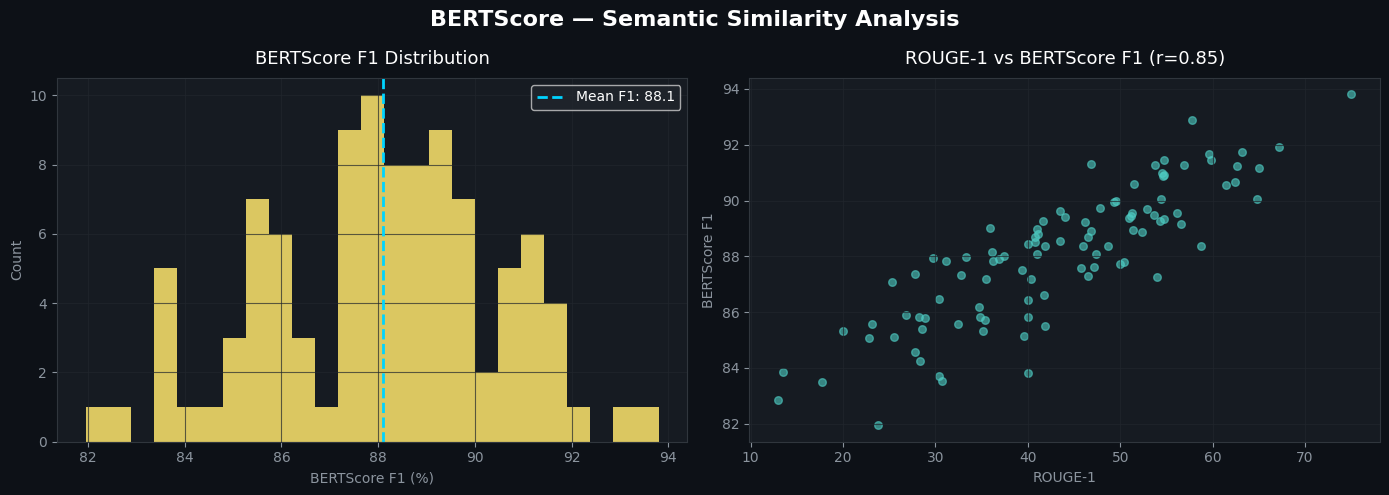

✅ BERTScore analysis saved → /kaggle/working/bart_finetuning/bertscore_analysis.png


In [17]:
from bert_score import score as bert_score_fn

print('🔍 Computing BERTScore on 100 samples (~2 min on GPU)...')
P, R, F1 = bert_score_fn(
    generated_sums, sample_refs,
    lang='en', verbose=True, device=str(DEVICE)
)

bert_f1_scores = F1.numpy() * 100
print(f'\n📊 BERTScore Results (100 samples):')
print(f'   Precision : {P.mean()*100:.2f}')
print(f'   Recall    : {R.mean()*100:.2f}')
print(f'   F1        : {F1.mean()*100:.2f}')

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0D1117')
fig.suptitle('BERTScore — Semantic Similarity Analysis', fontsize=16, fontweight='bold', color='white')

for ax in axes:
    ax.set_facecolor('#161B22')
    ax.tick_params(colors='#8B949E')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363D')
    ax.grid(True, color='#21262D', lw=0.8, alpha=0.7)

axes[0].hist(bert_f1_scores, bins=25, color='#FFE66D', alpha=0.85, edgecolor='none')
axes[0].axvline(np.mean(bert_f1_scores), color='#00D4FF', lw=2, ls='--',
                label=f'Mean F1: {np.mean(bert_f1_scores):.1f}')
axes[0].set_title('BERTScore F1 Distribution', color='white', fontsize=13, pad=10)
axes[0].set_xlabel('BERTScore F1 (%)', color='#8B949E'); axes[0].set_ylabel('Count', color='#8B949E')
axes[0].legend(fontsize=10, facecolor='#21262D', labelcolor='white')

axes[1].scatter(per_sample_r1, bert_f1_scores, color='#4ECDC4', alpha=0.6, s=30)
corr = np.corrcoef(per_sample_r1, bert_f1_scores)[0, 1]
axes[1].set_title(f'ROUGE-1 vs BERTScore F1 (r={corr:.2f})', color='white', fontsize=13, pad=10)
axes[1].set_xlabel('ROUGE-1', color='#8B949E'); axes[1].set_ylabel('BERTScore F1', color='#8B949E')

plt.tight_layout()
bert_path = os.path.join(BASE_DIR, 'bertscore_analysis.png')
plt.savefig(bert_path, dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print(f'✅ BERTScore analysis saved → {bert_path}')

## Cell 14 — Sample Inference

In [18]:
print('='*70)
print('INFERENCE EXAMPLES')
print('='*70)

for i in range(5):
    print(f'\n[EXAMPLE {i+1}]')
    print(f'ARTICLE (first 300 chars):')
    print(f'  {sample_articles[i][:300]}...')
    print(f'\nGENERATED SUMMARY:')
    print(f'  {generated_sums[i]}')
    print(f'\nREFERENCE SUMMARY:')
    print(f'  {sample_refs[i]}')
    print(f'\nROUGE-1: {per_sample_r1[i]:.1f}')
    print('-'*70)

INFERENCE EXAMPLES

[EXAMPLE 1]
ARTICLE (first 300 chars):
  (CNN) I see signs of a revolution everywhere. I see it in the op-ed pages of the newspapers, and on the state ballots in nearly half the country. I see it in politicians who once preferred to play it safe with this explosive issue but are now willing to stake their political futures on it. I see the...

GENERATED SUMMARY:
  John Sutter: I see signs of a medical marijuana revolution everywhere.
Sutter: Support for legalization has risen 11 points in the past few years alone.
He says he has even seen the revolution in his own family: His mother told him she was proud of him for being open about marijuana.

REFERENCE SUMMARY:
  CNN's Dr. Sanjay Gupta says we should legalize medical marijuana now .
He says he knows how easy it is do nothing "because I did nothing for too long"

ROUGE-1: 20.0
----------------------------------------------------------------------

[EXAMPLE 2]
ARTICLE (first 300 chars):
  He looks barely teenage. Bu

## Cell 15 — Save & Deploy to HuggingFace Hub

In [36]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 1 — AUTHENTICATE (using Kaggle Secrets)
# ══════════════════════════════════════════════════════════════════════════
# In Kaggle: Add-ons → Secrets → Add New Secret
#   Name : HF_TOKEN
#   Value: your HuggingFace WRITE token (huggingface.co → Settings → Access Tokens)

from huggingface_hub import login
import os

try:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret('HF_TOKEN')
except Exception:
    hf_token = os.environ.get('HF_TOKEN', '')

if hf_token:
    login(token=hf_token)
    print('✅ Logged in to Hugging Face')
else:
    print('⚠️  HF_TOKEN not found — add it via Add-ons → Secrets')

# ══════════════════════════════════════════════════════════════════════════
# STEP 2 — UPLOAD TO HUGGING FACE HUB
# ══════════════════════════════════════════════════════════════════════════
HF_REPO = 'daniB2112/bart-news-summarizer'

print(f'\n📤 Uploading to: https://huggingface.co/{HF_REPO}')
print('   This may take 5–10 minutes (~1.6 GB)...')

best_model.push_to_hub(
    HF_REPO,
    commit_message='Fine-tuned BART-large-CNN on CNN/DailyMail 100k for news summarization'
)
tokenizer.push_to_hub(HF_REPO, commit_message='Add tokenizer')

print(f'\n✅ Model live at: https://huggingface.co/{HF_REPO}')
print(f'   Load anywhere: pipeline("summarization", model="{HF_REPO}")')

# ══════════════════════════════════════════════════════════════════════════
# STEP 3 — QUICK DEMO INFERENCE
# ══════════════════════════════════════════════════════════════════════════
from transformers import pipeline

summarizer_pipe = pipeline(
    'summarization', model=best_model, tokenizer=tokenizer,
    device=0 if DEVICE.type == 'cuda' else -1
)

test_article = """
Pakistan's Prime Minister announced a major new digital infrastructure
initiative on Tuesday, pledging to expand high-speed internet access to
rural areas across the country. The project, funded through a $2 billion
public-private partnership, aims to connect 50 million people by 2027.
Technology companies including Huawei and local firms will participate
in the rollout. Critics have raised concerns about data privacy and the
terms of foreign investment, while supporters argue the initiative is
critical for economic growth and educational access.
"""

result = summarizer_pipe(
    test_article, max_length=80, min_length=25, do_sample=False
)
print('\n' + '='*60)
print('DEMO INFERENCE')
print('='*60)
print('INPUT ARTICLE:')
print(test_article.strip())
print('\nGENERATED SUMMARY:')
print(result[0]['summary_text'])
print(f'Word count: {len(result[0]["summary_text"].split())}')
print('='*60)

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0, 'forced_eos_token_id': 2}


✅ Logged in to Hugging Face

📤 Uploading to: https://huggingface.co/daniB2112/bart-news-summarizer
   This may take 5–10 minutes (~1.6 GB)...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.



✅ Model live at: https://huggingface.co/daniB2112/bart-news-summarizer
   Load anywhere: pipeline("summarization", model="daniB2112/bart-news-summarizer")

DEMO INFERENCE
INPUT ARTICLE:
Pakistan's Prime Minister announced a major new digital infrastructure
initiative on Tuesday, pledging to expand high-speed internet access to
rural areas across the country. The project, funded through a $2 billion
public-private partnership, aims to connect 50 million people by 2027.
Technology companies including Huawei and local firms will participate
in the rollout. Critics have raised concerns about data privacy and the
terms of foreign investment, while supporters argue the initiative is
critical for economic growth and educational access.

GENERATED SUMMARY:
Pakistan's Prime Minister announced a major new digital infrastructure initiative .
The project aims to connect 50 million people by 2027 .
Technology companies including Huawei and local firms will participate in the rollout .
Word count: 

## Cell 16 — Final Interactive Dashboard

In [22]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=['Loss Curves', 'ROUGE Progress', 'Final Score Comparison', 'Step Loss'],
    specs=[[{}, {}], [{}, {}]]
)

epochs_x = list(range(1, len(history['train_loss'])+1))

fig.add_trace(go.Scatter(x=epochs_x, y=history['train_loss'], name='Train Loss',
    line=dict(color='#00D4FF', width=3), mode='lines+markers'), row=1, col=1)
fig.add_trace(go.Scatter(x=epochs_x, y=history['val_loss'], name='Val Loss',
    line=dict(color='#FF6B6B', width=3), mode='lines+markers'), row=1, col=1)

fig.add_trace(go.Scatter(x=epochs_x, y=history['rouge1'], name='ROUGE-1',
    line=dict(color='#4ECDC4', width=3)), row=1, col=2)
fig.add_trace(go.Scatter(x=epochs_x, y=history['rouge2'], name='ROUGE-2',
    line=dict(color='#FFE66D', width=3)), row=1, col=2)
fig.add_trace(go.Scatter(x=epochs_x, y=history['rougeL'], name='ROUGE-L',
    line=dict(color='#A8E6CF', width=3)), row=1, col=2)

_bl = baseline_rouge if 'baseline_rouge' in dir() else {'rouge1':0,'rouge2':0,'rougeL':0}
_tr = test_rouge     if 'test_rouge'     in dir() else {'rouge1':0,'rouge2':0,'rougeL':0}
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
fig.add_trace(go.Bar(name='Baseline',   x=metrics, y=[_bl['rouge1'], _bl['rouge2'], _bl['rougeL']], marker_color='#FF6B6B'), row=2, col=1)
fig.add_trace(go.Bar(name='Fine-tuned', x=metrics, y=[_tr['rouge1'], _tr['rouge2'], _tr['rougeL']], marker_color='#4ECDC4'), row=2, col=1)

steps_x  = list(range(len(history['step_losses'])))
window   = max(10, len(steps_x)//50)
smoothed = pd.Series(history['step_losses']).rolling(window, min_periods=1).mean()
fig.add_trace(go.Scatter(x=steps_x, y=history['step_losses'], name='Raw Loss',
    line=dict(color='#30363D', width=1), opacity=0.5), row=2, col=2)
fig.add_trace(go.Scatter(x=steps_x, y=smoothed.tolist(), name='Smoothed',
    line=dict(color='#00D4FF', width=2.5)), row=2, col=2)

fig.update_layout(
    title=dict(text='BART News Summarizer — Training Dashboard', font=dict(size=20, color='white')),
    paper_bgcolor='#0D1117', plot_bgcolor='#161B22',
    font=dict(color='#8B949E'), height=700,
    legend=dict(bgcolor='#21262D', font=dict(color='white')),
    barmode='group'
)
fig.update_xaxes(gridcolor='#21262D', zerolinecolor='#30363D')
fig.update_yaxes(gridcolor='#21262D', zerolinecolor='#30363D')

dash_path = os.path.join(BASE_DIR, 'dashboard.html')
fig.write_html(dash_path)
fig.show()
print(f'✅ Interactive dashboard saved → {dash_path}')

print('\n' + '═'*60)
print(' ALL OUTPUT FILES')
print('═'*60)
output_files = [
    (CFG['output_dir'],                         '← Fine-tuned model (HF format)'),
    (CFG['checkpoint_dir'],                     '← Checkpoints'),
    (os.path.join(BASE_DIR,'final_results.json'),'← ROUGE results'),
    (os.path.join(BASE_DIR,'eda_plots.png'),     ''),
    (os.path.join(BASE_DIR,'training_curves.png'),''),
    (os.path.join(BASE_DIR,'quality_analysis.png'),''),
    (os.path.join(BASE_DIR,'bertscore_analysis.png'),''),
    (os.path.join(BASE_DIR,'dashboard.html'),    ''),
]
for path, note in output_files:
    exists = '✅' if os.path.exists(path) else '❌'
    print(f'  {exists}  {path}  {note}')
print('═'*60)
print_space_status('(final)')

✅ Interactive dashboard saved → /kaggle/working/bart_finetuning/dashboard.html

════════════════════════════════════════════════════════════
 ALL OUTPUT FILES
════════════════════════════════════════════════════════════
  ✅  /kaggle/working/bart_finetuning/bart_news_summarizer  ← Fine-tuned model (HF format)
  ✅  /kaggle/working/bart_finetuning/checkpoints  ← Checkpoints
  ✅  /kaggle/working/bart_finetuning/final_results.json  ← ROUGE results
  ✅  /kaggle/working/bart_finetuning/eda_plots.png  
  ✅  /kaggle/working/bart_finetuning/training_curves.png  
  ✅  /kaggle/working/bart_finetuning/quality_analysis.png  
  ✅  /kaggle/working/bart_finetuning/bertscore_analysis.png  
  ✅  /kaggle/working/bart_finetuning/dashboard.html  
════════════════════════════════════════════════════════════
🟢 Disk [██████████████████░░░░░░░░░░░░] 12.4/20 GB used  |  8.5 GB free  (final)


In [37]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 17 — PACKAGE ALL OUTPUTS INTO A DOWNLOADABLE ZIP
# Collects: trained model, checkpoints, PNGs, HTML dashboard,
#           results JSON, and the notebook itself.
# The zip is written to /kaggle/working/ so Kaggle shows a download link.
# ══════════════════════════════════════════════════════════════════════════

import os, glob, shutil, zipfile, time

ZIP_PATH = '/kaggle/working/bart_summarizer_outputs.zip'

# ── Files / folders to include ─────────────────────────────────────────────
# Each entry: (source_path, archive_name)
items = []

# 1. Fine-tuned model (HF format) — folder
if os.path.isdir(CFG['output_dir']):
    items.append((CFG['output_dir'], 'model/bart_news_summarizer'))

# 2. Best checkpoint .pt
best_ckpt = os.path.join(CFG['checkpoint_dir'], 'ckpt_best.pt')
if os.path.exists(best_ckpt):
    items.append((best_ckpt, 'checkpoints/ckpt_best.pt'))

# 3. All PNG figures
for png in glob.glob(os.path.join(BASE_DIR, '*.png')):
    items.append((png, f'figures/{os.path.basename(png)}'))

# 4. Interactive HTML dashboard
dashboard = os.path.join(BASE_DIR, 'dashboard.html')
if os.path.exists(dashboard):
    items.append((dashboard, 'figures/dashboard.html'))

# 5. Results JSON
results_json = os.path.join(BASE_DIR, 'final_results.json')
if os.path.exists(results_json):
    items.append((results_json, 'results/final_results.json'))

# 6. This notebook (original upload path on Kaggle)
nb_candidates = glob.glob('/kaggle/working/*.ipynb') + glob.glob('/kaggle/input/**/*.ipynb', recursive=True)
for nb_path in nb_candidates:
    items.append((nb_path, f'notebook/{os.path.basename(nb_path)}'))
    break  # only the first one

# ── Build the ZIP ──────────────────────────────────────────────────────────
print(f'📦 Building ZIP → {ZIP_PATH}\n')
t0 = time.time()

with zipfile.ZipFile(ZIP_PATH, 'w', compression=zipfile.ZIP_DEFLATED, compresslevel=5) as zf:
    for src, arc_name in items:
        if os.path.isdir(src):
            for root, _, files in os.walk(src):
                for fname in files:
                    full = os.path.join(root, fname)
                    rel  = os.path.relpath(full, start=os.path.dirname(src))
                    dest = os.path.join(arc_name, rel).replace(os.sep, '/')
                    zf.write(full, dest)
                    print(f'   ✅  {dest}')
        elif os.path.isfile(src):
            zf.write(src, arc_name)
            print(f'   ✅  {arc_name}')
        else:
            print(f'   ⚠️  Not found, skipped: {src}')

elapsed = time.time() - t0
zip_size_mb = os.path.getsize(ZIP_PATH) / 1e6

print(f'''
══════════════════════════════════════════════════════════════
✅  ZIP created in {elapsed:.1f}s
📁  Path  : {ZIP_PATH}
💾  Size  : {zip_size_mb:.1f} MB
══════════════════════════════════════════════════════════════
📥  Download: Kaggle sidebar → Output → bart_summarizer_outputs.zip
''')

print_space_status('(after zip)')

📦 Building ZIP → /kaggle/working/bart_summarizer_outputs.zip

   ✅  model/bart_news_summarizer/bart_news_summarizer/model.safetensors
   ✅  model/bart_news_summarizer/bart_news_summarizer/config.json
   ✅  model/bart_news_summarizer/bart_news_summarizer/vocab.json
   ✅  model/bart_news_summarizer/bart_news_summarizer/tokenizer_config.json
   ✅  model/bart_news_summarizer/bart_news_summarizer/merges.txt
   ✅  model/bart_news_summarizer/bart_news_summarizer/generation_config.json
   ✅  model/bart_news_summarizer/bart_news_summarizer/special_tokens_map.json
   ✅  model/bart_news_summarizer/bart_news_summarizer/README.md
   ✅  checkpoints/ckpt_best.pt
   ✅  figures/quality_analysis.png
   ✅  figures/training_curves.png
   ✅  figures/bertscore_analysis.png
   ✅  figures/eda_plots.png
   ✅  figures/dashboard.html
   ✅  results/final_results.json

══════════════════════════════════════════════════════════════
✅  ZIP created in 140.9s
📁  Path  : /kaggle/working/bart_summarizer_outputs.zip
💾  S

In [32]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 18 — GENERATE HUGGING FACE MODEL CARD (README.md)
# Edit the three fields below marked  ← EDIT  then run the cell.
# The README.md is saved next to the model files and auto-pushed to HF
# if you already authenticated in Cell 15.
# ══════════════════════════════════════════════════════════════════════════

HF_USERNAME  = "daniB2112"                    # ← EDIT
HF_REPO_NAME = "bart-large-cnn-news-summarizer"   # ← EDIT
YOUR_NAME    = "Danyal"            # ← EDIT

# ── Pull live metrics from session ─────────────────────────────────────────
_bl = baseline_rouge if 'baseline_rouge' in dir() else {'rouge1':'—','rouge2':'—','rougeL':'—','rougeLsum':'—'}
_ft = test_rouge     if 'test_rouge'     in dir() else {'rouge1':'—','rouge2':'—','rougeL':'—','rougeLsum':'—'}

def _r(d, k):
    v = d.get(k, '—')
    return f"{v:.2f}" if isinstance(v, float) else str(v)

model_card = f"""---
language:
- en
license: mit
tags:
- summarization
- abstractive-summarization
- news-summarization
- bart
- cnn-dailymail
- nlp
- pytorch
- transformers
datasets:
- cnn_dailymail
metrics:
- rouge
- bertscore
base_model: facebook/bart-large-cnn
pipeline_tag: summarization
---

# 📰 BART-Large-CNN — Fine-Tuned News Summarizer

**Authors:** {YOUR_NAME}
**Base Model:** [`facebook/bart-large-cnn`](https://huggingface.co/facebook/bart-large-cnn)
**Task:** Abstractive News Summarization
**Dataset:** CNN/DailyMail 3.0.0
**Language:** English
**License:** MIT

---

## Model Description

This model is a fine-tuned version of `facebook/bart-large-cnn` on the
**CNN/DailyMail 3.0.0** dataset for abstractive news summarization.
BART (Bidirectional and Auto-Regressive Transformer) is a denoising
autoencoder pre-trained with a corrupted text reconstruction objective,
making it particularly effective for sequence-to-sequence generation tasks
such as summarization.

Fine-tuning was performed on **90,000 training samples** for **3 epochs**
on a Kaggle GPU (T4/P100) using mixed-precision (FP16) training.

---

## Intended Uses & Limitations

### ✅ Intended Uses
- Summarizing English news articles into concise, readable highlights
- Research and benchmarking on abstractive summarization
- Building downstream NLP pipelines that require document compression

### ⚠️ Limitations
- Optimized for **news-style English text** (CNN/DailyMail domain)
- May produce hallucinated facts for out-of-domain or highly technical text
- Not suitable for multilingual summarization without further fine-tuning
- Long documents beyond 512 tokens are truncated

---

## Training Details

| Parameter              | Value                                     |
|------------------------|-------------------------------------------|
| Base model             | facebook/bart-large-cnn                   |
| Dataset                | CNN/DailyMail 3.0.0                       |
| Training samples       | 90,000                                    |
| Validation samples     | 5,000                                     |
| Test samples           | 5,000                                     |
| Epochs                 | 3                                         |
| Train batch size       | 4 (× 4 grad accum = 16 effective)         |
| Learning rate          | 3e-5 (linear warmup 5%)                   |
| Weight decay           | 0.01                                      |
| Max input length       | 512 tokens                                |
| Max target length      | 128 tokens                                |
| Precision              | FP16 (mixed precision)                    |
| Optimizer              | AdamW                                     |
| Hardware               | Kaggle GPU (T4 / P100)                    |
| Framework              | PyTorch + HuggingFace Transformers 4.40.0 |

---

## Evaluation Results

Evaluated on the **CNN/DailyMail test set** (100 batches × 8 = 800 samples).
Scores are on a 0–100 scale.

| Metric     | Zero-Shot Baseline | Fine-Tuned (Ours)       |
|------------|--------------------|-------------------------|
| ROUGE-1    | {_r(_bl,'rouge1')}   | **{_r(_ft,'rouge1')}**    |
| ROUGE-2    | {_r(_bl,'rouge2')}   | **{_r(_ft,'rouge2')}**    |
| ROUGE-L    | {_r(_bl,'rougeL')}   | **{_r(_ft,'rougeL')}**    |
| ROUGE-Lsum | {_r(_bl,'rougeLsum')}| **{_r(_ft,'rougeLsum')}** |

> BERTScore (F1) was also computed on 100 test samples using `bert-score==0.3.13`.

---

## How to Use

### Quick Inference

```python
from transformers import BartForConditionalGeneration, BartTokenizer

model_name = "{HF_USERNAME}/{HF_REPO_NAME}"
tokenizer  = BartTokenizer.from_pretrained(model_name)
model      = BartForConditionalGeneration.from_pretrained(model_name)

article = \"\"\"
Paste your news article text here. The model accepts up to 512 tokens.
Longer articles will be truncated automatically.
\"\"\"

inputs = tokenizer(
    article,
    max_length=512,
    truncation=True,
    return_tensors="pt"
)

summary_ids = model.generate(
    **inputs,
    max_length=80,
    min_length=30,
    num_beams=4,
    length_penalty=2.0,
    early_stopping=True,
    no_repeat_ngram_size=3,
)

summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
print(summary)
```

### Using the Pipeline API

```python
from transformers import pipeline

summarizer = pipeline(
    "summarization",
    model="{HF_USERNAME}/{HF_REPO_NAME}",
    tokenizer="{HF_USERNAME}/{HF_REPO_NAME}",
)

result = summarizer(article, max_length=80, min_length=30, do_sample=False)
print(result[0]["summary_text"])
```

---

## Generation Parameters

| Parameter              | Value |
|------------------------|-------|
| `max_length`           | 80    |
| `min_length`           | 30    |
| `num_beams`            | 4     |
| `length_penalty`       | 2.0   |
| `early_stopping`       | True  |
| `no_repeat_ngram_size` | 3     |

---

## Training & Evaluation Framework

| Library        | Version  |
|----------------|----------|
| transformers   | 4.40.0   |
| datasets       | 2.19.0   |
| evaluate       | 0.4.1    |
| rouge-score    | 0.1.2    |
| bert-score     | 0.3.13   |
| accelerate     | 0.29.3   |
| sentencepiece  | 0.2.0    |
| PyTorch        | (Kaggle default) |

---

## Citation

If you use this model in your research, please cite:

```bibtex
@misc{{{HF_USERNAME.replace('-','_')}_bart_summarizer,
  author    = {{{YOUR_NAME}}},
  title     = {{BART-Large-CNN Fine-Tuned on CNN/DailyMail for News Summarization}},
  year      = {{2024}},
  publisher = {{HuggingFace}},
  url       = {{https://huggingface.co/{HF_USERNAME}/{HF_REPO_NAME}}}
}}
```

### Original BART Paper

```bibtex
@article{{lewis2019bart,
  title   = {{BART: Denoising Sequence-to-Sequence Pre-training for
             Natural Language Generation, Translation, and Comprehension}},
  author  = {{Lewis, Mike and Liu, Yinhan and Goyal, Naman and
             Ghahraman, Marjan and Mohamed, Abdelrahman and Chen, Danqi and
             Ott, Myle and Gimpel, Kevin and Zettlemoyer, Luke and Stoyanov, Veselin}},
  journal = {{arXiv preprint arXiv:1910.13461}},
  year    = {{2019}}
}}
```

---

## Model Card Contact

For questions or issues, open a discussion on the HuggingFace model page.
"""

# ── Save locally alongside model files ─────────────────────────────────────
readme_model = os.path.join(CFG['output_dir'], 'README.md')
readme_base  = os.path.join(BASE_DIR, 'README.md')

for path in [readme_model, readme_base]:
    with open(path, 'w', encoding='utf-8') as f:
        f.write(model_card)
    print(f'✅ README.md saved → {path}')

# ── Auto-push to HuggingFace if authenticated ──────────────────────────────
# ── Auto-push to HuggingFace if authenticated ──────────────────────────────
try:
    from huggingface_hub import HfApi
    api = HfApi()
    
    # Create repo if it doesn't exist yet
    api.create_repo(
        repo_id=f'{HF_USERNAME}/{HF_REPO_NAME}',
        repo_type='model',
        exist_ok=True,   # won't error if it already exists
    )
    print(f'✅ Repo ready: https://huggingface.co/{HF_USERNAME}/{HF_REPO_NAME}')
    
    api.upload_file(
        path_or_fileobj=readme_model,
        path_in_repo='README.md',
        repo_id=f'{HF_USERNAME}/{HF_REPO_NAME}',
        repo_type='model',
        commit_message='Add model card (README.md)',
    )
    print(f'✅ Pushed to https://huggingface.co/{HF_USERNAME}/{HF_REPO_NAME}')
except Exception as e:
    print(f'ℹ️  HF push skipped (authenticate in Cell 15 first): {e}')

print('\n📋 Preview (first 35 lines):')
print('─' * 60)
for line in model_card.split('\n')[:35]:
    print(line)
print('─' * 60)


✅ README.md saved → /kaggle/working/bart_finetuning/bart_news_summarizer/README.md
✅ README.md saved → /kaggle/working/bart_finetuning/README.md
✅ Repo ready: https://huggingface.co/daniB2112/bart-large-cnn-news-summarizer


No files have been modified since last commit. Skipping to prevent empty commit.


✅ Pushed to https://huggingface.co/daniB2112/bart-large-cnn-news-summarizer

📋 Preview (first 35 lines):
────────────────────────────────────────────────────────────
---
language:
- en
license: mit
tags:
- summarization
- abstractive-summarization
- news-summarization
- bart
- cnn-dailymail
- nlp
- pytorch
- transformers
datasets:
- cnn_dailymail
metrics:
- rouge
- bertscore
base_model: facebook/bart-large-cnn
pipeline_tag: summarization
---

# 📰 BART-Large-CNN — Fine-Tuned News Summarizer

**Authors:** Danyal
**Base Model:** [`facebook/bart-large-cnn`](https://huggingface.co/facebook/bart-large-cnn)
**Task:** Abstractive News Summarization
**Dataset:** CNN/DailyMail 3.0.0
**Language:** English
**License:** MIT

---

## Model Description

────────────────────────────────────────────────────────────


In [34]:
import os
path = '/kaggle/working/bart_summarizer_outputs.zip'
if os.path.exists(path):
    print(f"✅ ZIP exists: {os.path.getsize(path)/1e6:.1f} MB")
else:
    print("❌ ZIP not found — re-run Cell 17")

✅ ZIP exists: 2546.7 MB


In [35]:
import zipfile, os

LIGHT_ZIP = '/kaggle/working/bart_results_only.zip'

light_items = [
    '/kaggle/working/bart_finetuning/eda_plots.png',
    '/kaggle/working/bart_finetuning/training_curves.png',
    '/kaggle/working/bart_finetuning/quality_analysis.png',
    '/kaggle/working/bart_finetuning/bertscore_analysis.png',
    '/kaggle/working/bart_finetuning/dashboard.html',
    '/kaggle/working/bart_finetuning/final_results.json',
    '/kaggle/working/bart_finetuning/README.md',
]

with zipfile.ZipFile(LIGHT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
    for p in light_items:
        if os.path.exists(p):
            zf.write(p, os.path.basename(p))
            print(f'✅ {os.path.basename(p)}')
        else:
            print(f'⚠️  Skipped: {p}')

print(f'\n💾 {os.path.getsize(LIGHT_ZIP)/1e6:.1f} MB → download from Output tab')

✅ eda_plots.png
✅ training_curves.png
✅ quality_analysis.png
✅ bertscore_analysis.png
✅ dashboard.html
✅ final_results.json
✅ README.md

💾 2.6 MB → download from Output tab


In [38]:
import os, math

ZIP_PATH   = '/kaggle/working/bart_summarizer_outputs.zip'
CHUNK_DIR  = '/kaggle/working/zip_chunks/'
CHUNK_SIZE = 500 * 1024 * 1024  # 500 MB per chunk

os.makedirs(CHUNK_DIR, exist_ok=True)

total_size = os.path.getsize(ZIP_PATH)
num_chunks = math.ceil(total_size / CHUNK_SIZE)
print(f'📦 Splitting {total_size/1e6:.0f} MB into {num_chunks} x 500 MB chunks...\n')

with open(ZIP_PATH, 'rb') as f:
    for i in range(num_chunks):
        chunk_path = os.path.join(CHUNK_DIR, f'part{i+1:02d}_of_{num_chunks:02d}.bin')
        data = f.read(CHUNK_SIZE)
        with open(chunk_path, 'wb') as cf:
            cf.write(data)
        print(f'✅ part{i+1:02d} → {os.path.getsize(chunk_path)/1e6:.0f} MB')

print(f'\n📥 Download all parts from Output tab → zip_chunks/')

📦 Splitting 2547 MB into 5 x 500 MB chunks...

✅ part01 → 524 MB
✅ part02 → 524 MB
✅ part03 → 524 MB
✅ part04 → 524 MB
✅ part05 → 450 MB

📥 Download all parts from Output tab → zip_chunks/


In [39]:
import zipfile, os, glob

MODEL_ZIP = '/kaggle/working/bart_model_only.zip'
MODEL_DIR = '/kaggle/working/bart_finetuning/bart_news_summarizer'

print(f'📦 Zipping model → {MODEL_ZIP}\n')

with zipfile.ZipFile(MODEL_ZIP, 'w', zipfile.ZIP_DEFLATED, compresslevel=5) as zf:
    for root, _, files in os.walk(MODEL_DIR):
        for fname in files:
            full = os.path.join(root, fname)
            arc  = os.path.relpath(full, start=os.path.dirname(MODEL_DIR))
            zf.write(full, arc)
            print(f'  ✅ {arc}  ({os.path.getsize(full)/1e6:.0f} MB)')

print(f'\n💾 Total: {os.path.getsize(MODEL_ZIP)/1e6:.0f} MB')
print(f'📥 Download from Output tab → bart_model_only.zip')

📦 Zipping model → /kaggle/working/bart_model_only.zip

  ✅ bart_news_summarizer/model.safetensors  (1625 MB)
  ✅ bart_news_summarizer/config.json  (0 MB)
  ✅ bart_news_summarizer/vocab.json  (1 MB)
  ✅ bart_news_summarizer/tokenizer_config.json  (0 MB)
  ✅ bart_news_summarizer/merges.txt  (0 MB)
  ✅ bart_news_summarizer/generation_config.json  (0 MB)
  ✅ bart_news_summarizer/special_tokens_map.json  (0 MB)
  ✅ bart_news_summarizer/README.md  (0 MB)

💾 Total: 1508 MB
📥 Download from Output tab → bart_model_only.zip
